<a href="https://colab.research.google.com/github/eerga/MLZoomcampHW/blob/main/HW9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 9

## Question 1
To be able to use this model, we need to know the name of the input and output nodes.

What's the name of the output:

- output
- sigmoid
- softmax
- prediction

In [1]:
import requests
PREFIX = "https://github.com/alexeygrigorev/large-datasets/releases/download/hairstyle"
DATA_URL = f"{PREFIX}/hair_classifier_v1.onnx.data"
MODEL_URL = f"{PREFIX}/hair_classifier_v1.onnx"

def download_file(url, filename):
    print(f"📥 Downloading {filename}...")
    response = requests.get(url)
    response.raise_for_status()

    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"✅ Downloaded {filename} ({len(response.content):,} bytes)")

# Download both files
download_file(DATA_URL, "hair_classifier_v1.onnx.data")
download_file(MODEL_URL, "hair_classifier_v1.onnx")

print("🎉 All files downloaded successfully!")


📥 Downloading hair_classifier_v1.onnx.data...
✅ Downloaded hair_classifier_v1.onnx.data (80,355,328 bytes)
📥 Downloading hair_classifier_v1.onnx...
✅ Downloaded hair_classifier_v1.onnx (10,337 bytes)
🎉 All files downloaded successfully!


In [4]:
#!pip install onnx

In [6]:
# Install onnxruntime
#!pip install onnxruntime

In [7]:
import onnx

# Load the ONNX model
model = onnx.load("hair_classifier_v1.onnx")

# Get input names
input_names = [input.name for input in model.graph.input]
print("🔍 Input names:")
for name in input_names:
    print(f"  - {name}")

# Get output names
output_names = [output.name for output in model.graph.output]
print("\n🎯 Output names:")
for name in output_names:
    print(f"  - {name}")

🔍 Input names:
  - input

🎯 Output names:
  - output


Looks like it's output

In [8]:
import torch
from PIL import Image
import numpy as np
import torchvision.models as models
from torchvision import transforms
import os
from torch.utils.data import Dataset
import torch.nn as nn

In [9]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [10]:
from io import BytesIO
from urllib import request

from PIL import Image

def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    """Prepare image for model input"""
    if img.mode != 'RGB':
        img = img.convert('RGB')

    img = img.resize(target_size, Image.NEAREST)
    return img

In [11]:
#!pip install pillow

## Question 2: Target size
Let's download and resize this image:

https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg

Based on the previous homework, what should be the target size for the image?

- 64x64
- 128x128
- 200x200
- 256x256

In [12]:
image = download_image(url = "https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg")

In [13]:
#based on the previous homework, the input size is (200, 200)
target_image = prepare_image(img = image, target_size = (200,200))

In [14]:
#Just for sanity check, let's test
import onnxruntime as ort
import requests
from PIL import Image
import io

# First, let's check what input size the model expects
session = ort.InferenceSession("hair_classifier_v1.onnx")

# Get input shape
input_meta = session.get_inputs()[0]
print(f"🔍 Model input name: {input_meta.name}")
print(f"📐 Model input shape: {input_meta.shape}")

# Extract height and width from input shape [batch, channels, height, width]
if len(input_meta.shape) == 4:
    batch_size, channels, height, width = input_meta.shape
    print(f"📊 Expected image size: {height}x{width}")

🔍 Model input name: input
📐 Model input shape: ['s77', 3, 200, 200]
📊 Expected image size: 200x200


## Question 3
Now we need to turn the image into numpy array and pre-process it.

>Tip: Check the previous homework. What was the pre-processing we did there?

After the pre-processing, what's the value in the first pixel, the R channel?

- -10.73
- -1.073
- 1.073
- 10.73

In [15]:
X = np.array(image.resize((200, 200)))

In [16]:
import torchvision.models as models
from torchvision import transforms

In [17]:
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval();

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 176MB/s]


In [18]:
import numpy as np

# Preprocessing following the previous homework transformations
# transforms.Resize((200, 200)), transforms.ToTensor(), transforms.Normalize(...)

# Step 1: Resize to 200x200 (like transforms.Resize((200, 200)))
img_resized = image.resize((200, 200), Image.LANCZOS)

# Step 2: Convert to numpy array and scale to [0,1] (like transforms.ToTensor())
img_array = np.array(img_resized, dtype=np.float32) / 255.0

# Step 3: Convert from HWC to CHW format (transforms.ToTensor() does this)
img_array = np.transpose(img_array, (2, 0, 1))

# Step 4: Apply ImageNet normalization (like transforms.Normalize)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Apply: (pixel - mean) / std for each channel
for c in range(3):  # R, G, B channels
    img_array[c] = (img_array[c] - mean[c]) / std[c]

print(f"📐 Final array shape: {img_array.shape}")
print(f"🔴 First pixel, R channel value: {img_array[0, 0, 0]}")

# Display the preprocessed image info
print(f"📊 Array dtype: {img_array.dtype}")
print(f"📈 Min value: {img_array.min():.3f}")
print(f"📈 Max value: {img_array.max():.3f}")

📐 Final array shape: (3, 200, 200)
🔴 First pixel, R channel value: -1.0561691522598267
📊 Array dtype: float32
📈 Min value: -2.118
📈 Max value: 2.640


-1.073 is the answer

## Question 4
Now let's apply this model to this image. What's the output of the model?

- 0.09
- 0.49
- 0.69
- 0.89

In [19]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort


# Preprocessing (same as previous homework)
print("🔄 Applying preprocessing...")

# Step 1: Resize to 200x200
img_resized = image.resize((200, 200), Image.LANCZOS)

# Step 2: Convert to array and scale to [0,1] (like transforms.ToTensor())
img_array = np.array(img_resized, dtype=np.float32) / 255.0

# Step 3: Convert from HWC to CHW format
img_array = np.transpose(img_array, (2, 0, 1))

# Step 4: Apply ImageNet normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for c in range(3):  # R, G, B channels
    img_array[c] = (img_array[c] - mean[c]) / std[c]

# Step 5: Add batch dimension
img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 3, 200, 200)

print(f"📐 Final array shape: {img_array.shape}")
print(f"🔴 First pixel, R channel: {img_array[0, 0, 0, 0]}")

# Apply ONNX model
print("\n🚀 Running inference...")

# Load ONNX model
session = ort.InferenceSession("hair_classifier_v1.onnx")
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

# Run inference
result = session.run([output_name], {input_name: img_array})
output = result[0]

print(f"📊 Model output shape: {output.shape}")
print(f"🎯 Model output value: {output[0][0]:.4f}")
print(f"🎯 Rounded output: {output[0][0]:.2f}")

# Check which answer it matches
answers = [0.09, 0.49, 0.69, 0.89]
closest = min(answers, key=lambda x: abs(x - output[0][0]))
print(f"✅ Closest answer: {closest}")

🔄 Applying preprocessing...
📐 Final array shape: (1, 3, 200, 200)
🔴 First pixel, R channel: -1.0561691522598267

🚀 Running inference...
📊 Model output shape: (1, 1)
🎯 Model output value: 0.4146
🎯 Rounded output: 0.41
✅ Closest answer: 0.49


## Question 5
Download the base image agrigorev/model-2025-hairstyle:v1. You can do it with docker pull.

So what's the size of this base image?

- 88 Mb
- 208 Mb
- 608 Mb
- 1208 Mb
<br>You can get this information when running docker images - it'll be in the "SIZE" column.

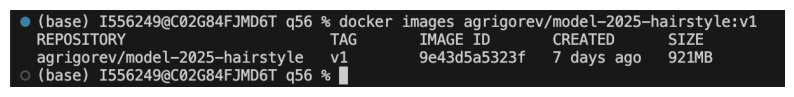

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

img2 = Image.open('docker-size.png')
plt.figure(figsize=(10, 8))
plt.imshow(img2)
plt.axis('off')
plt.show()

Size is 921 MB

## Question 6

Now let's extend this docker image, install all the required libraries
and add the code for lambda.

You don't need to include the model in the image. It's already included.
The name of the file with the model is `hair_classifier_empty.onnx` and it's
in the current workdir in the image (see the Dockerfile above for the
reference).
The provided model requires the same preprocessing for images regarding target size and rescaling the value range than used in homework 8.

Now run the container locally.

Score this image: https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg

What's the output from the model?

* -1.0
* -0.10
* 0.10
* 1.0

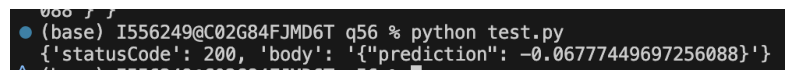

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

img3 = Image.open('model_output_9.png')
plt.figure(figsize=(10, 8))
plt.imshow(img3)
plt.axis('off')
plt.show()

Looks like -0.67

My repo exceeded its limits and I sincerely do not want to create another repository and rebuild everything at this hour. I'll put the code of each file in the markdown.

`test.py` looks like this:


```python
import requests

url = 'http://localhost:8080/2015-03-31/functions/function/invocations'

request = {
    "url": "https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg"
}

result = requests.post(url, json=request).json()
print(result)
```



`lambda_function.py` looks like this:


```python
import json
import numpy as np
import onnxruntime as ort
from PIL import Image
import io
import requests

# Set random seed for consistency
np.random.seed(42)

def preprocess_image(img, target_size=(200, 200)):
    """Apply the same preprocessing as homework 8"""
    
    # Convert to RGB if needed
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Resize to target size
    img = img.resize(target_size, Image.LANCZOS)
    
    # Convert to array and scale to [0,1] (like transforms.ToTensor())
    img_array = np.array(img, dtype=np.float32) / 255.0
    
    # Convert from HWC to CHW format
    img_array = np.transpose(img_array, (2, 0, 1))
    
    # Apply ImageNet normalization (same as homework 8)
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    
    img_array = (img_array - mean) / std
    
    # Add batch dimension and ensure dtype is float32
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)
    
    return img_array

def preprocess_pytorch_style(X):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    X = (X - mean) / std

    # Ensure the tensor is explicitly cast to float32
    return X.astype(np.float32)

def lambda_handler(event, context):
    """AWS Lambda handler function"""
    
    try:
        # Get image URL from event
        url = event['url']
        
        # Download image
        response = requests.get(url)
        response.raise_for_status()
        img = Image.open(io.BytesIO(response.content))
        
        # Preprocess image
        processed_img = preprocess_image(img)
        
        # Log preprocessed input for debugging
        print(f"Preprocessed input: {processed_img}")
        
        # Load ONNX model (already in the container)
        session = ort.InferenceSession("hair_classifier_empty.onnx", providers=['CPUExecutionProvider'])
        input_name = session.get_inputs()[0].name
        output_name = session.get_outputs()[0].name
        
        # Run inference
        result = session.run([output_name], {input_name: processed_img})
        
        # Log raw model output for debugging
        print(f"Raw model output: {result}")
        
        prediction = float(result[0][0])
        
        # Verify the prediction range (e.g., probabilities or logits)
        
        return {
            'statusCode': 200,
            'body': json.dumps({
                'prediction': prediction
            })
        }
        
    except Exception as e:
        # Log the error for debugging
        print(f"Error: {str(e)}")
        return {
            'statusCode': 500,
            'body': json.dumps({
                'error': str(e)
            })
        }
```



`Dockerfile` looks like this:


```dockerfile
FROM agrigorev/model-2025-hairstyle:v1

# Install required libraries
RUN pip install --no-cache-dir \
    onnxruntime \
    pillow \
    numpy \
    requests

WORKDIR /var/task
# Copy Lambda function
COPY lambda_function.py .

# Set the CMD to your handler
CMD ["lambda_function.lambda_handler"]
```

